# Personal Information
Name: **Elena Spano**

StudentID: **14444593**

Email: [**elena.spano@student.uva.nl**](youremail@student.uva.nl)

GitHub link: https://github.com/ele-spano22/master-thesis

Submitted on: **09.03.2026**

# Data Context
This thesis uses symbolic music datasets to investigate whether tonal mode (major vs. minor) is encoded in the internal representations of Transformer-based symbolic music models trained with a next-token prediction objective. The primary dataset used is the DCML corpus, an open-source collection of annotated classical music corpora curated by the DCMLab and available on GitHub at https://github.com/DCMLab/dcml_corpora.

A secondary dataset is also used: the Essen Folksong dataset, which is available here: https://github.com/ccarh/essen-folksong-collection.

**RQ**: Is tonal mode (major vs. minor) linearly decodable from the hidden representations of a Transformer trained for symbolic
music modeling with a next-token prediction objective?




# Data Description

Dataset overview:

• Number of corpuses: 12

• Total music pieces (after data cleaning): 537 

• Number of variables: 71

• Major mode pieces: 321 (59.8%)

• Minor mode pieces: 216 (40.2%)

### **EDA summary**

After the pre-processing step, the dataset contains 537 musical pieces with approximately 71 (this number was higher but some columns where dropped because completely empty) metadata variables describing tonal, structural, and editorial aspects of the pieces. Each row in the dataset corresponds to a single musical piece, while each column corresponds with a musical attribute. For this study, the most relevant columns are those related to tonal information (annotated key, from which both tonic and tonal mode were extracted for the purpose of the EDA analysis), structural properties like time signature and piece length, and dataset metadata like corpus and instrument type. Editorial metadata fields (typesetter, transcriber, poet, external links, etc.) were not used for the analysis.

I extracted tonal mode directly from the annotated_key column. This is because in the DCML dataset, as is very standard practice in music notation, uppercase key annotations indicate major mode and lowercase annotations indicate minor mode. Based on this, I created a new variable (mode) with two classes: major and minor. There were some pieces (N = 23) without annotated key information, which I removed, so the final dataset contained 321 major pieces (59.8%) and 216 minor pieces (40.2%). The newly computed mode variable was used for this EDA analysis, but this is also the main variable that contains ground truth information and will be used as the binary labels used to test the accuracy (and other metrics) of my main model (Note: naturally the model will NOT see the labels during training. They will only be used after).

I performed several univariate and multivariate analyses to better understand the dataset. These included examining the distribution of tonal centers, time signatures, piece lengths, and instrument types. Overall, the dataset shows a slight imbalance toward major pieces, which is to be expected in Western classical music. Therefore, the simple majority-class baseline at the bottom of the EDA analysis achieved an accuracy of approximately 59.8%, which will serve as a reference point for my main predictive model later in the project.

I also examined piece length distributions. Major and minor pieces show similar overall length distributions, with no statistically significant difference between the two groups based on an independent t-test. This suggests that tonal mode does not strongly influence the overall duration of pieces in the dataset. I conducted several chi-square tests to explore relationships between categorical variables. The results show that tonic and tonal mode are strongly related, which is expected because tonal centers are naturally tied to specific major or minor contexts in Western tonal music. The implications of this result on the main analysis are discussed in the sections below. There was also a moderate relationship between corpus and tonal mode, which suggested that different composers and their specific collections do indeed favor certain tonalities. On the other hand, both instrument type and time signature showed no statistically significant relationship with tonal mode, which suggests that these factors are largely independent from the major/minor distinction in this dataset.

The EDA analysis confirms that the dataset is suitable for the main experiments of this project. The dataset is quite biased toward piano repertoire, which could potentially influence tonal distributions and will be considered when interpreting model results. As for the rest of the dataset qualities, the variables are well-defined, the class imbalance in tonal mode is very moderate, and the distributions of the other variables that I observed across the 12 corpuses are in line with expectations from Western tonal music theory. 

**Conclusion**: A key finding from this EDA analysis is that tonic and pitch distribution are strongly associated with tonal mode. This implies that tonal mode could, to some extent, be predicted from relatively simple pitch statistics. This means that the probing analysis that I will later conduct in the main part of this project should demonstrate performance that goes beyond such surface-level information. Namely, the baseline model used in this study relies on simple pitch distribution statistics, which currently achieve an accuracy of approximately 60%. The expectation is then that a Transformer-based model will achieve higher predictive performance because it can encode more abstract musical context through its internal representations. However, if the Transformer model does not significantly exceed the baseline performance, this would suggest that tonal mode can sufficiently emerge from surface-level pitch statistics alone rather than from deeper structural representations.

In [345]:
# Imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency 


## Analysis 1: Dataset structure

### Data Loading

The data that I will be needing for this project is inside metadata files saved as metadata.tsv. Since the corpus contains 12 different corpora (divided by composer), there should be 12 metadata files. 

In [272]:
# loading all the metadata.tsv files in the corpora
data_path = Path("../data/dcml_corpora")
metadata_files = list(data_path.rglob("metadata.tsv"))
len(metadata_files)


12

As expected, I am working with 12 metadata files. I will take a look at the common column names across all 12 corpuses to see where the information I need could be:

In [273]:
# grouping the metadata files by common columns to find the tonal mode encoding column
common_columns = None
for file in metadata_files:
    df = pd.read_csv(file, sep="\t", nrows=5)
    cols = set(df.columns)
    if common_columns is None:
        common_columns = cols
    else:
        common_columns = common_columns.intersection(cols)
print(sorted(common_columns))

['KeySig', 'TimeSig', 'all_notes_qb', 'ambitus', 'annotated_key', 'annotators', 'arranger', 'composed_end', 'composed_start', 'composer', 'composer_text', 'copyright', 'creationDate', 'form_label_count', 'guitar_chord_count', 'has_drumset', 'label_count', 'last_mc', 'last_mc_unfolded', 'last_mn', 'last_mn_unfolded', 'length_qb', 'length_qb_unfolded', 'lyricist', 'movementNumber', 'movementTitle', 'ms3_version', 'mscVersion', 'musescore', 'n_onset_positions', 'n_onsets', 'piece', 'platform', 'poet', 'rel_path', 'reviewers', 'source', 'staff_1_ambitus', 'staff_1_instrument', 'staff_2_ambitus', 'staff_2_instrument', 'subdirectory', 'title_text', 'translator', 'volta_mcs', 'workNumber', 'workTitle']


From inspecting the column names, I can see 2 column names that might contain the information that I am looking for, "KeySig" and "annotated_key". I will take a look at what they look like to decide which variable is the one I need by indexing with "key".

In [275]:
key_columns = [col for col in common_columns if "key" in col.lower()]
for col in key_columns:
    print(col)

KeySig
annotated_key


So indeed, in each corpus in the corpora, there are 2 columns with key in the names, KeySig, and annotated_key. I will take a look at what kind of information they contain to see which variable is the one I need. 

In [278]:
df = pd.read_csv(metadata_files[0], sep="\t")
print(df["KeySig"].head())
print(df["annotated_key"].head())

0    1: -1
1    1: -1
2    1: -1
3    1: -1
4     1: 1
Name: KeySig, dtype: str
0    F
1    d
2    F
3    F
4    G
Name: annotated_key, dtype: str


After inspecting KeySig, this is not the information I am looking for, so annotated_key is where tonal mode information about a given piece is stored. Let's see what it looks like:

In [279]:
metadata_list = []
for corpus in data_path.iterdir():
    if corpus.is_dir():
        metadata_file = corpus / "metadata.tsv"
        if metadata_file.exists():
            df = pd.read_csv(metadata_file, sep="\t")
            df["corpus"] = corpus.name
            metadata_list.append(df)

metadata = pd.concat(metadata_list, ignore_index=True)
metadata["annotated_key"].dropna().unique()[:20]

<StringArray>
[ 'F',  'd',  'G',  'C',  'D', 'Bb',  'c',  'A', 'Eb',  'f',  'e',  'E',  'a',
 'Ab', 'bb', 'Db', 'c#',  'b', 'g#', 'f#']
Length: 20, dtype: str

From what I can see above, tonal mode information is not explicit in the way it is stored, meaning it's not "minor" or "major". This is common in music notation. The uppercase letters indicate major pieces, while the lowercase letters indicate minor pieces. Key of course is specified by letter. That being said, it will be easier for me to conduct this EDA and interpret the results as well as the rest of the project if I turn this notation into explicit major vs. minor storage. In section 3, I will take the uppercase letters and assign them the label of "major" while I will assign the label of "minor" to lowercase letter, across all corpuses in the corpora (12). 

Before I move on, I will check other structural characteristics of the dataset to make sure everything is in check. Firstly, let's look at the strcuture of our metadata.

In [280]:
metadata.shape

(560, 74)

We have 560 rows (meaning that 1 row = 1 piece) and 74 columns (1 column = musical characteristics per piece). I did this before to identify key information, but now let's print again the column names to see exactly what type of data is stored in our dataset, which will inform what kind of exploratory analyses we can perform later.

In [224]:
print(metadata.columns)

Index(['piece', 'TimeSig', 'KeySig', 'last_mc', 'last_mn', 'length_qb',
       'last_mc_unfolded', 'last_mn_unfolded', 'length_qb_unfolded',
       'volta_mcs', 'all_notes_qb', 'n_onsets', 'n_onset_positions',
       'guitar_chord_count', 'form_label_count', 'label_count',
       'annotated_key', 'harmony_version', 'annotators', 'reviewers',
       'composed_start', 'composed_end', 'composer', 'workTitle',
       'movementNumber', 'movementTitle', 'workNumber', 'poet', 'lyricist',
       'arranger', 'copyright', 'creationDate', 'mscVersion', 'platform',
       'source', 'translator', 'title_text', 'lyricist_text', 'composer_text',
       'musescore', 'ms3_version', 'subdirectory', 'rel_path', 'has_drumset',
       'ambitus', 'comments', 'originalFormat', 'staff_1_ambitus',
       'staff_1_instrument', 'staff_2_ambitus', 'staff_2_instrument',
       'staff_3_ambitus', 'staff_3_instrument', 'staff_4_ambitus',
       'staff_4_instrument', 'corpus', 'score_integrity', 'composed_source',
  

Looking at the available variables, we have a mixture of musical structure variables, analytical annotations, and editorial metadata. For the purposes of this thesis, the most relevant variables are those that describe musical properties of the pieces, which in this case are annotated_key, mode (which I just created myself), and TimeSig, which provide tonal and metric information. Some other interesting features that are more about the structure of a piece are length_qb, last_mc, last_mn, n_onsets, which describe aspects of the musical score like piece length, number of measures, and note density. THese could be useful for EDA later. 

A large portion of the metadata though consists of editorial or bibliographic information, namely typesetter, transcriber, electronic editor, source, pdf, imslp, musicbrainz, wikidata, etc. These variables are not informative on musical content so they are not relevant for this analysis and will therefore be ignored in the following sections. There are also some text-related fields (title_text, lyricist_text, subtitle_text, etc.) that fall outside the scope of this study. 

Now let's look at how many pieces each corpus contains.

In [225]:
metadata["corpus"].value_counts()

corpus
corelli                      149
beethoven_piano_sonatas       87
ABC                           70
grieg_lyric_pieces            66
chopin_mazurkas               55
mozart_piano_sonatas          54
liszt_pelerinage              19
medtner_tales                 19
schumann_kinderszenen         13
tchaikovsky_seasons           12
dvorak_silhouettes            12
debussy_suite_bergamasque      4
Name: count, dtype: int64

Let's also check what variable types we are working with, so we know what types of analyses we can conduct with the variables and how to access them.

In [284]:
print(metadata.dtypes.head(20))

piece                     str
TimeSig                   str
KeySig                    str
last_mc                 int64
last_mn                 int64
length_qb             float64
last_mc_unfolded      float64
last_mn_unfolded      float64
length_qb_unfolded    float64
volta_mcs              object
all_notes_qb          float64
n_onsets                int64
n_onset_positions       int64
guitar_chord_count      int64
form_label_count        int64
label_count             int64
annotated_key             str
harmony_version           str
annotators                str
reviewers                 str
dtype: object


## Analysis 2: Missing values

An important part of EDA is to check if there are any missing values/other issues to address in the data before performing any analyses.

In [297]:
print(metadata.isna().sum().sort_values(ascending=False).head(20))

translator            560
arranger              560
poet                  560
lyricist              559
transcriber           556
text                  556
imslp.1               555
comments              554
PDF                   541
lyricist_text         537
electronic editor     537
electronic encoder    537
score integrity       536
key                   505
mode                  505
typesetter            488
volta_mcs             474
staff_4_instrument    441
pdf                   438
staff_3_instrument    421
dtype: int64


As we can see, many of the columns in the dataset are completely empty and some are mostly empty. This is okay, since I will not be needing any of this information for my project. Therefore, I will remove the empty columns completely from the dataset as they serve no purpose but I will keep the ones that contain some amount of information across a portion of the pieces.

In [298]:
empty_cols = metadata.columns[metadata.isna().sum() == len(metadata)]
metadata = metadata.drop(columns=empty_cols)


### Missing values (for annotated key)

In [299]:
metadata["annotated_key"].isna().sum()

np.int64(23)

As we can see, there are 23 missing values in the annotated_key column across the dataset. 

I will drop these rows from the dataset and then classify annotated_key as major or minor to obtain my labels. This decision is made on the basis of the fact that I simply cannot derive tonal mode without an explicit key label, so these rows are of no use to me. Since there are 560 pieces in the dataset, removing 23 is taking out a very very small portion of the dataset (less than 4%), so I am okay with dropping these rows.

In [302]:
metadata = metadata.dropna(subset=["annotated_key"])
print("Dataset size after removing missing keys:", metadata.shape)

Dataset size after removing missing keys: (537, 71)


Now our datasets contains 537 rows (pieces) and 71 columns (musical attributes) for the annotated_key column. 

### Missing values (for instrument type)

We have the variable staff_1_instrument, which contains information on the instrument used for a musical piece. This could be a very interesting variable for our EDA, so let's check if it requires any cleaning and what it looks like so we can work with it later.

In [232]:
metadata["staff_1_instrument"].value_counts()

staff_1_instrument
Piano                 98
piano                 73
Violin                58
Midi_1                42
Piano (2)             36
organ                 24
Klavier linke Hand    23
StringInstrument      23
MusicXML Default 1    16
Violin I (2)          12
unbenannt2             6
unbenannt              4
Grand Piano            1
S.                     1
Klavier                1
Name: count, dtype: int64

The current issue with this list of instruments is that many names point to the same instrument (piano) but appear as different categories, which is wrong. There are also entries that do not point to actual instruments but simply to encoding artifacts (like Midi_1), which we should ignore, or entries that refer to the instrument being unknown (unbenannt). I will group all names falling into the category of piano into 1 and normalize the other entries best that I can.

In [304]:
# first lowercasing all the entries
metadata["instrument_clean"] = metadata["staff_1_instrument"].str.lower()
# then replacing the different entries with the same name with a common name
metadata["instrument_clean"] = metadata["instrument_clean"].replace({
    
    "piano": "piano",
    "grand piano": "piano",
    "piano (2)": "piano",
    # these entries are in German but they also refer to the piano, so I will group them together with the other piano entries
    "klavier": "piano",
    "klavier linke hand": "piano",
    
    "violin": "violin",
    "violin i (2)": "violin",
    
    "organ": "organ",
    
    "stringinstrument": "string",
    # these entries don't refer to an instrument but to the fact that the instrument is unknown, so i will group them together in a category of unknown
    "midi_1": "unknown",
    "musicxml default 1": "unknown",
    "unbenannt": "unknown",
    "unbenannt2": "unknown",
    "s.": "unknown"
})
metadata["instrument_clean"].value_counts()

instrument_clean
piano      232
violin      70
unknown     69
organ       24
string      23
Name: count, dtype: int64

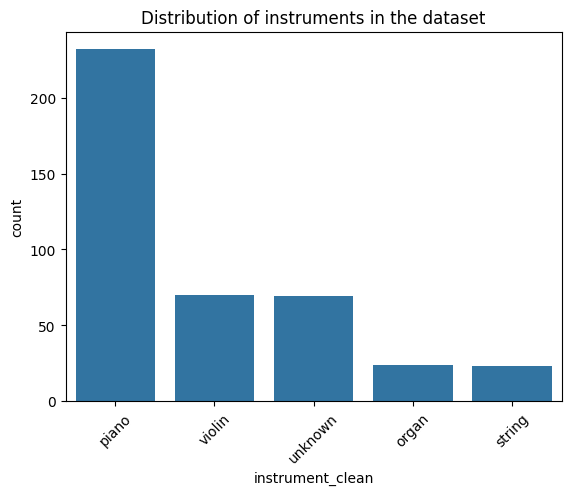

In [306]:
sns.countplot(
    data=metadata,
    x="instrument_clean",
    order=metadata["instrument_clean"].value_counts().index
)
plt.title("Distribution of instruments in the dataset")
plt.xticks(rotation=45)
plt.show()

Now, the instrument variable is usable for our analysis. It is clear however that most of the dataset contains piano pieces, which makes the distribution imbalanced. I will keep this in mind as I utilize this variable in the later sections. It is also worth noting that the use of this variable is for exploratory and visualization purposes only, so the imbalance is not entirely relevant.

## Analysis 3: Basic statistics

Now I will compute basic statistics for our numerical variables. This is good for getting an idea of the distributions of my numerical variables.

In [235]:
metadata.describe()

,last_mc,last_mn,length_qb,last_mc_unfolded,last_mn_unfolded,length_qb_unfolded,all_notes_qb,n_onsets,n_onset_positions,guitar_chord_count,form_label_count,label_count,composed_start,composed_end,movementNumber,mscVersion
count,537.000000,537.000000,537.000000,535.000000,535.000000,535.000000,537.000000,537.000000,537.000000,537.000000,537.0,537.000000,537.000000,537.000000,462.000000,5.360000e+02
mean,108.573557,107.983240,337.106592,140.095327,139.009346,434.042972,1068.762998,1537.646182,741.188082,0.009311,0.0,214.392924,1793.752328,1794.832402,3.006494,3.020000e+00
std,98.597812,98.290679,311.535773,127.464368,126.616092,398.380013,984.046367,1480.799094,712.886593,0.113898,0.0,164.824602,74.311517,75.266082,2.089630,4.445041e-16
min,2.000000,2.000000,8.000000,2.000000,2.000000,8.000000,12.000000,12.000000,4.000000,0.000000,0.0,4.000000,1681.000000,1681.000000,1.000000,3.020000e+00
25%,39.000000,38.000000,135.000000,54.000000,54.000000,173.750000,444.000000,519.000000,235.000000,0.000000,0.0,95.000000,1694.000000,1694.000000,2.000000,3.020000e+00
50%,75.000000,74.000000,222.000000,90.000000,90.000000,300.000000,718.580000,999.000000,461.000000,0.000000,0.0,156.000000,1802.000000,1802.000000,3.000000,3.020000e+00
75%,151.000000,150.000000,432.000000,193.500000,192.500000,558.500000,1380.330000,2054.000000,1073.000000,0.000000,0.0,295.000000,1843.000000,1846.000000,4.000000,3.020000e+00
max,554.000000,553.000000,2000.000000,672.000000,664.000000,2192.000000,5885.890000,11682.000000,4586.000000,2.000000,0.0,871.000000,1925.000000,1925.000000,13.000000,3.020000e+00


Most of the data looks fine. As we identified above, in the later columns there are some missing values across, however this is not a problem for me as I will not be using any of these variables during this project, so I will ignore that instead of removing/replacing the NaN values.

### Piece lenght distribution

I will also use a histogram to visualize, overall, the lenght of our corpora pieces. This will tell us whether the pieces in the dataset are short or long (on a spectrum, that is).

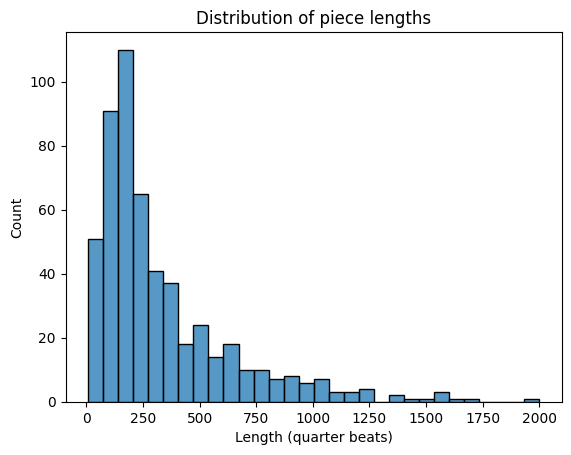

In [236]:
sns.histplot(metadata["length_qb"], bins=30)
plt.title("Distribution of piece lengths")
plt.xlabel("Length (quarter beats)")
plt.show()

The histogram shows a pronounced left skew, meaning that most of the pieces in the dataset are on the shorter end of the spectrum, which makes sense considering the corpora that we are working with. There are some very long pieces but they are few and far between. 

## Analysis 4: Variable construction

### *Creating a mode variable with tonal mode binary labels*

Now that I have a better understanding of the data I am working with and I removed all missing values from annotated_key, I can create my major vs. minor labels.

In [310]:
# here, I extract the first character of the key label and check if it is uppercase
metadata["mode"] = metadata["annotated_key"].str[0].str.isupper().map({
    True: "major", # if it is uppercase → major
    False: "minor" # if it is lowercase → minor
})

# check the distribution of major vs minor pieces in the dataset.
metadata["mode"].value_counts(dropna=False)
metadata[["annotated_key", "mode"]].head(10)

,annotated_key,mode
0,F,major
1,d,minor
2,F,major
3,F,major
4,G,major
5,C,major
6,G,major
7,G,major
8,D,major
9,Bb,major


I have now created a new variable in the dataset named "mode" that contains binary labels about a piece's tonal mode: major or minor. This is a variable I will use extensively during EDA but it is also the variable that contains the ground truth labels for the main model later in the project.

In [311]:
print(metadata[["mode"]].shape)

(537, 1)


The next thing I need to check is class balance. Oftentimes in music, pieces tend to be major more often than they are minor. This can cause issues during model training and testing, so it is good to check the distribution now. 

In [312]:
print(metadata["mode"].value_counts())
print(metadata["mode"].value_counts(normalize=True))


mode
major    321
minor    216
Name: count, dtype: int64
mode
major    0.597765
minor    0.402235
Name: proportion, dtype: float64


I will also visualize this result with a simple plot with seaborn.

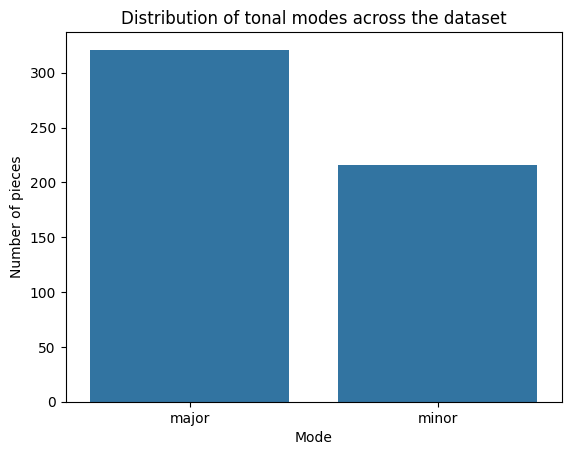

In [313]:
sns.countplot(data=metadata, x="mode")
plt.title("Distribution of tonal modes across the dataset")
plt.xlabel("Mode")
plt.ylabel("Number of pieces")
plt.show()

As we can see, the dataset contains 321 major pieces (59.8%) and 216 minor pieces (40.2%). This does indicate a mild class imbalance but there is definetely enough representation of both classes and is not imbalanced to a problematic level.

### *Creating a variable for tonic*

It will also be useful for me for later analysis to have a variable that contains tonic information. That is, currently annotated_key contains 2 pieces of information at once: tonic (A, B, C, etc.) and tonal mode (encoded in uppercase/lowercase). I already created a variable that explicitly labels a piece as major or minor (mode), so now I want to create a variable that assigns one tonic to each piece, based on the tonic in the annotated_key column. This is just a mor straightforward way to access both information pieces, tonal mode and tonic as 2 separate concepts. It is easier to do this time as the tonic is simply the letter that is in the annotated_key column at the moment. I will just need to turn them all into uppercase.

In [314]:
# obtain tonic by capitalizing the annotated_key column which will give us the tonic information in a more straightforward way
metadata["tonic"] = metadata["annotated_key"].str.capitalize()
metadata[["annotated_key", "tonic", "mode"]].head(20)

,annotated_key,tonic,mode
0,F,F,major
1,d,D,minor
2,F,F,major
3,F,F,major
4,G,G,major
5,C,C,major
6,G,G,major
7,G,G,major
8,D,D,major
9,Bb,Bb,major


As we can see, we have now broken down the 2 musical concepts that were previously contained in the annotated_key column into 2 separate variables: tonal mode and tonic.

## Analysis 5: Variable distribution (across corpora)

### *Number of pieces*

Something that is good to check is the distribution of pieces per corpus. Some composers have much bigger portfolios than others, so it is expected that some of the corpuses will contain more pieces than others.

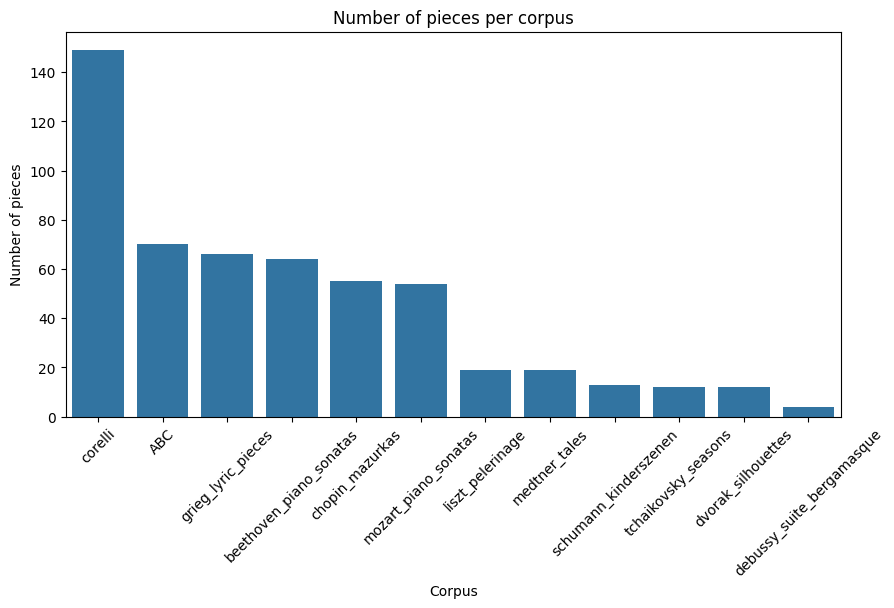

In [315]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=metadata,
    x="corpus",
    order=metadata["corpus"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Number of pieces per corpus")
plt.xlabel("Corpus")
plt.ylabel("Number of pieces")
plt.show()

As expected, some of the corpuses contain more pieces than others. The Corelli corpus contains the most pieces, while the Debussy one contains the least. This is not necessary a problem for me, since it is the case that all the composers in this corpora, no matter how big their portfolios are, have composed music that is suitable for my analysis. Whether one has produced more than the other is irrelevant, however just to be sure that there are no systematic differences in tonal mode across them I will perform a significance test in the Statistical testing section.

**Note**: Given the differences in sample sizes that we can see here, in this section I will normalize all plots to get a better understanding of realistic variable distributions.

### *Tonal mode*

The next thing to do is to check the distribution of tonal mode across corpuses (as a reminder, each corpus represents an individual composer). Generally speaking, there are composers that are known to write more major or minor pieces, so it is interesting to check this.

In [317]:
counts = pd.crosstab(metadata["corpus"], metadata["mode"])
percentages = pd.crosstab(metadata["corpus"], metadata["mode"], normalize="index") * 100
combined = pd.concat(
    [counts, percentages.round(1)],
    axis=1,
    keys=["Counts", "Percentages (%)"]
)
display(combined)

Counts       Percentages (%)      
mode                       major minor           major minor
corpus                                                      
ABC                           49    21            70.0  30.0
beethoven_piano_sonatas       45    19            70.3  29.7
chopin_mazurkas               28    27            50.9  49.1
corelli                       72    77            48.3  51.7
debussy_suite_bergamasque      2     2            50.0  50.0
dvorak_silhouettes             7     5            58.3  41.7
grieg_lyric_pieces            35    31            53.0  47.0
liszt_pelerinage              13     6            68.4  31.6
medtner_tales                  5    14            26.3  73.7
mozart_piano_sonatas          48     6            88.9  11.1
schumann_kinderszenen          9     4            69.2  30.8
tchaikovsky_seasons            8     4            66.7  33.3

Indeed, as expected, there are composers who mainly wrote major pieces (Mozart, Beethoven, ABC composers, Schumann, Listz), others whose distribution is fairly balanced (Chopin, Corelli, Debussy, Dvorak, Grieg), and others who mainly wrote minor pieces (Medtner). We can also visualize this with Seaborn. 

*Note*: I will normalize the plot since we saw pretty big differences in sample sizes across the corpuses. 

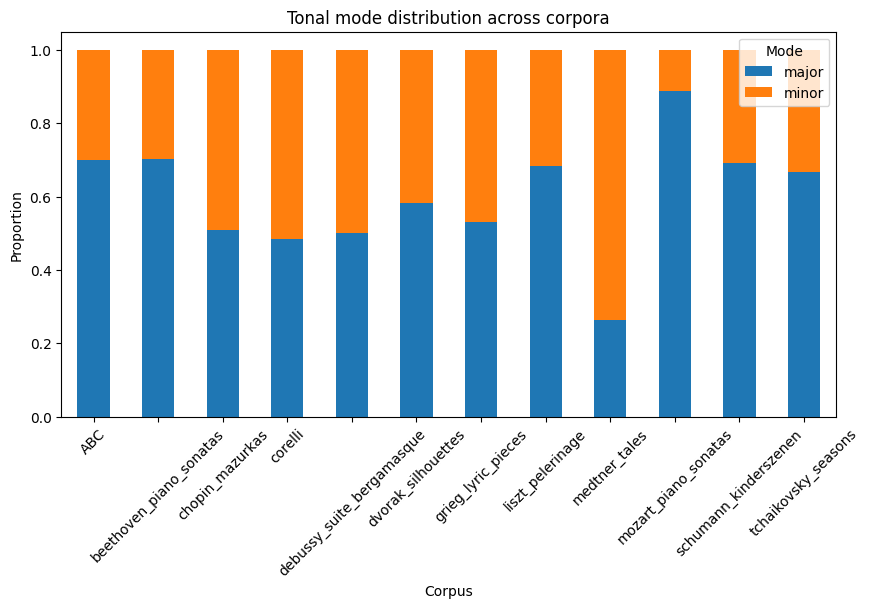

In [318]:
mode_corpus = pd.crosstab(
    metadata["corpus"],
    metadata["mode"],
    normalize="index"
)
mode_corpus.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)
plt.title("Tonal mode distribution across corpora")
plt.ylabel("Proportion")
plt.xlabel("Corpus")
plt.xticks(rotation=45)
plt.legend(title="Mode")
plt.show()

Similarly for the distribution of pieces across corpuses, it should not be a significant problem that some of the corpuses contain more major or minor pieces than others. This is to be expected in the field of music. However I will still perform a significance test in the later sections just to make sure there are no systematic differences in tonal mode across corpuses.

### *Tonic (by total number of pieces)*

Another thing that is good to take a look at is tonic distribution across the corpora. 

**Note**: This plot is not normalized.

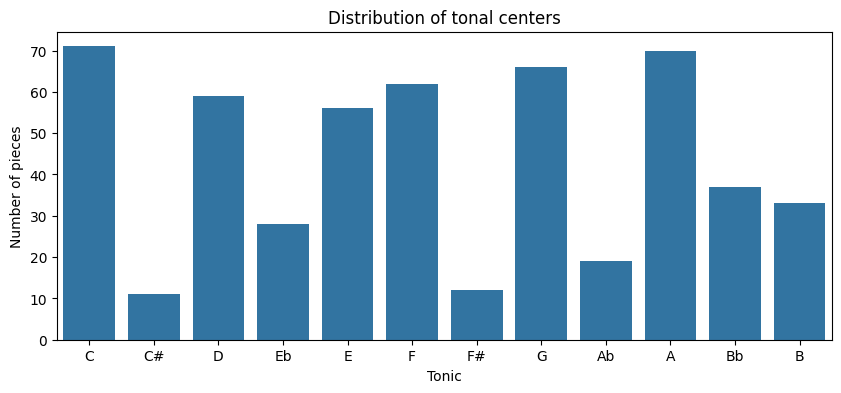

In [324]:
# this is just for visualization purposes, to have the keys in a specific order in the plot makes it easier to visually compare the distribution
key_order = [
    "C","C#","D","Eb","E","F",
    "F#","G","Ab","A","Bb","B"
]
plt.figure(figsize=(10,4))
sns.countplot(
    data=metadata,
    x="tonic",
    order=key_order
)
plt.title("Distribution of tonal centers")
plt.xlabel("Tonic")
plt.ylabel("Number of pieces")
plt.show()

We can see that some tonics are definetely favored over others. Musically, this is very normal and makes sense, also considering most of these pieces are on piano, and some of these keys are technically much harder to compose on and play than others on this instrument. Since tonal mode remains the focus of this paper, this is not a problem for this project and is in fact very much in line with what you would expect from a musical corpora.

### *Tonic (by corpuses)*

Besides visualizing tonic distribution across the pieces, another interesting insight to visualize is tonic distributions across corpuses (and therefore composers). For some of the reasons already discussed, some tonics are most commonly picked oevr others for a variety of musical reasons spanning the feeling, motif and expression that is wanting to be given to a musical piece.

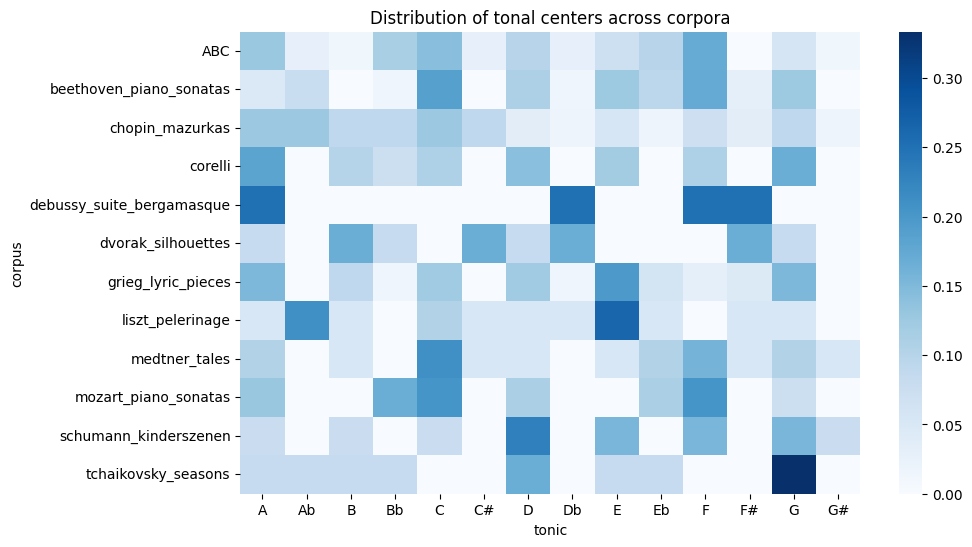

In [325]:
pd.crosstab(metadata["corpus"], metadata["tonic"])
key_corpus = pd.crosstab(metadata["corpus"], metadata["tonic"], normalize="index")
plt.figure(figsize=(10,6))
sns.heatmap(key_corpus, cmap="Blues")
plt.title("Distribution of tonal centers across corpora")
plt.show()

We can see that indeed some composers used more tonics more than others, notably Tchaikovsky, who used the G tonic a lot in his season compositions. Other notable ones are Debussy, who used A, Db, F and F# a lot and Liszt with the tonic E. Overall, however, I would say this distribution is pretty balanced.

## Analysis 6: Multivariate analysis 

Although I have already investigated some relationships between variables above already to get an understanding of the data that I am working with, I will use this section to check the most interesting combinations of the variables I am interested in for this project and see how they relate to one another.

## *Categorical interactions*

### Tonic by key

It is interesting to visualize the relationship between tonal mode and key to see if we see a systematic pattern across the two. For instance, in music it is common to have minor pieces in reoccuring tonics like A and E, simply because these are easier to play on piano, which we know most of this corpora is played on. On the other hand, there are tonics that are most commonly composed with in major. 

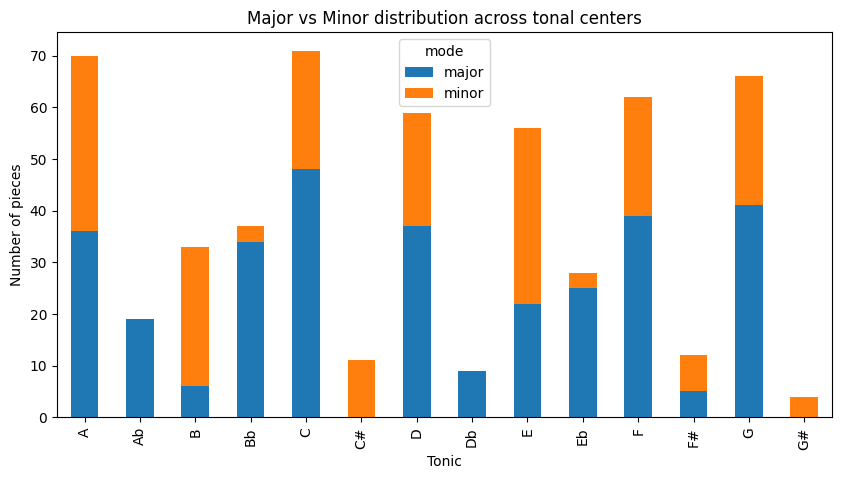

In [328]:
key_mode = pd.crosstab(metadata["tonic"], metadata["mode"])
key_mode.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Major vs Minor distribution across tonal centers")
plt.xlabel("Tonic")
plt.ylabel("Number of pieces")
plt.show()

As expected, the distribution of tonal mode across tonics is very interesting, and definetely very musically predictable. Tonics like A, E, G and D contain the most minor pieces, as well as the most pieces in general, out of all. This is because it is much harder to compose and, more importantly, play a minor piece on a tonic like Ab (which is why we see 0 minor pieces in this tonic across the corpora) than it is to do on tonic A. Interestingly, tonics G# and C# only contain minor pieces, which again makes sense thinking of the ease and difficulty levels of executing on these keys. In general, whether major or minor, more stable tonics (in layman's terms, the white keys on a piano) have been used more across classical music than the black keys. Therefore, this distribution is in line with what you would expect from a musical corpora.

### Time signature by tonal mode 

Time signature is an interesting musical insight, especially when taken together with tonal mode. In Western tonal music, major and minor modes are often associated with different expressive qualities. Major keys are typically perceived as brighter, and minor keys are frequently associated with more somber and dramatic musical character. Although these associations are common in music theory, they don't necessarily imply that there is a structural relationship with metrical organization. You might hypothesize that slower time signatures could occur more frequently in minor-mode pieces due to their perceived expressive character but this is not necessarily always the case. Regardless, it is good to check this.

<Axes: xlabel='timesig_simple'>

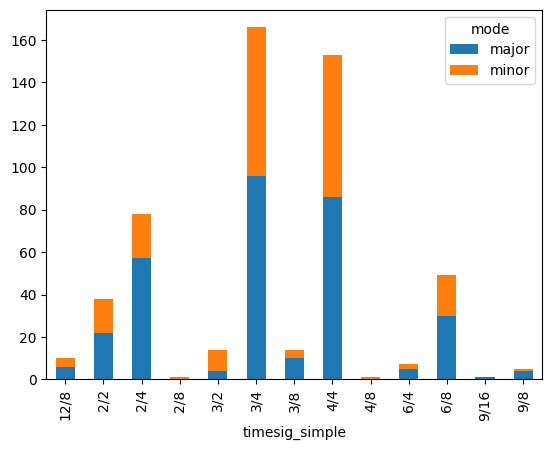

In [331]:
metadata["timesig_simple"] = metadata["TimeSig"].str.extract(r'(\d+/\d+)')
pd.crosstab(metadata["timesig_simple"], metadata["mode"])
pd.crosstab(metadata["timesig_simple"], metadata["mode"]).plot(
    kind="bar",
    stacked=True
)

Indeed, the distribution in the stacked bar chart does not suggest that there is a strong relationship between tonal mode and time signature. Both major and minor pieces appear across most meters. It would be helpful to see a normalized version of this chart, since there are such big differences in sample size across time signatures. This is what I will do next:

<Axes: xlabel='timesig_simple'>

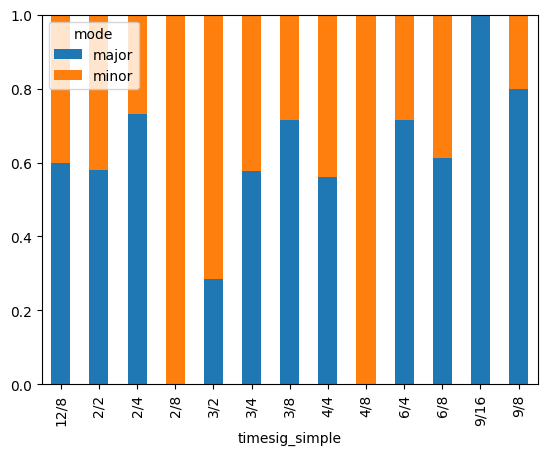

In [332]:
metadata["timesig_simple"] = metadata["TimeSig"].str.extract(r'(\d+/\d+)')
pd.crosstab(metadata["timesig_simple"], metadata["mode"])
pd.crosstab(metadata["timesig_simple"], metadata["mode"], normalize="index").plot(
    kind="bar",
    stacked=True
)

Now, we can see that indeed some time signatures do have mostly minor pieces (2/8, 4/8, even 3/2) while others mostly major pieces (9/16). However, overall I would not say there is a significant difference here. Just to be sure, I will test this in the later section.

### Piece lenght by tonal mode

Another thing that is interesting to visualize is piece lenght by tonal mode. Musically, I would not say that there typically is a difference in lenght of a piece depending on the tonal mode of the piece, but we can check this with a simple boxplot. 

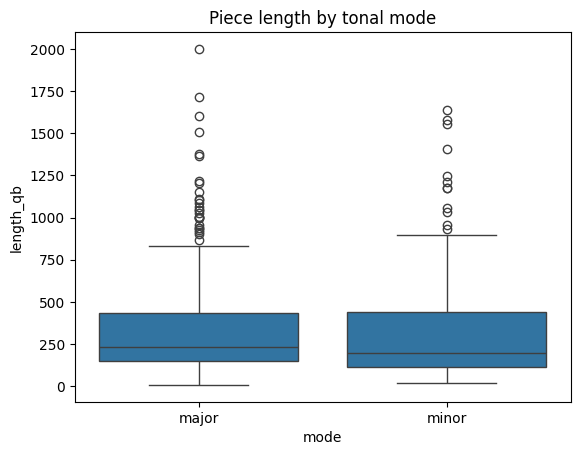

In [333]:
sns.boxplot(data=metadata, x="mode", y="length_qb")
plt.title("Piece length by tonal mode")
plt.show()

We can see that major and minor pieces seem to have pretty similar lengths overall. The medians are close, and the boxes overlap a lot, so there’s no obvious difference between the two modes. Both groups also have quite a few long outliers, meaning there are some unusually long pieces in both major and minor. If anything, major pieces look slightly longer on average, but the difference is small enough that it probably doesn’t mean much. I will check for a statistically significant difference in the later sections.

### Instrument by tonal mode

Although we know that most of the pieces in the corpora are piano pieces, it is good to check the distribution of tonal mode across the instruments in the dataset.

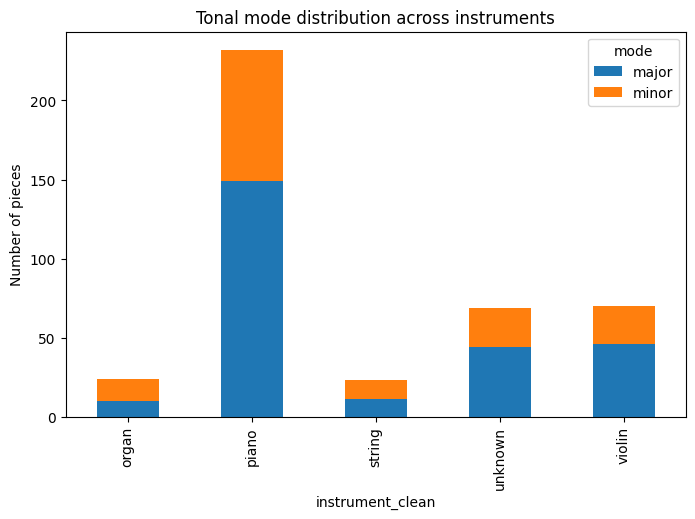

In [335]:
instrument_mode = pd.crosstab(
    metadata["instrument_clean"],
    metadata["mode"]
)
instrument_mode.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Tonal mode distribution across instruments")
plt.ylabel("Number of pieces")
plt.show()

This chart mostly shows that piano pieces dominate the dataset by a lot, which makes sense since many classical datasets focus heavily on piano music. Across most instrument categories, there are more major pieces than minor, but the difference isn’t huge. The smaller categories like organ and string have pretty few pieces overall, so it’s hard to read too much into those. Overall, nothing too surprising here. The dataset just seems piano-heavy, with a slightly higher number of major pieces across instruments. We can normalize this however to see if we get more meaningful insights, since again the piano sample size is very dominant here.

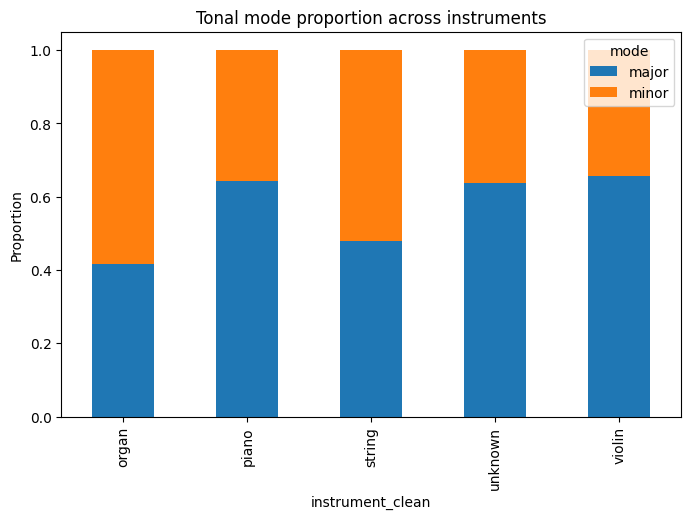

In [337]:
instrument_mode = pd.crosstab(
    metadata["instrument_clean"],
    metadata["mode"],
    normalize="index"
)
instrument_mode.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)
plt.title("Tonal mode proportion across instruments")
plt.ylabel("Proportion")
plt.show()

Now we can see that most instrument categories actually have more major pieces than minor, especially piano and violin where major makes up around two-thirds of the pieces. Organ is the only one that leans more toward minor, but that category is pretty small so it’s hard to draw strong conclusions from it. The pattern is pretty consistent: major mode is slightly more common across most instruments.

### Instrument by tonic 

We can also visualize the distribution of instruments across tonic centers. Although not central to my project, it is simply to get an idea of the relationships between the main variables in the study. Like I did before for all the others visualize, I will normalize since there are pretty big differences in sample sizes across many of these variables, and this helps us get a more realistic understanding of the relationships between our variables.

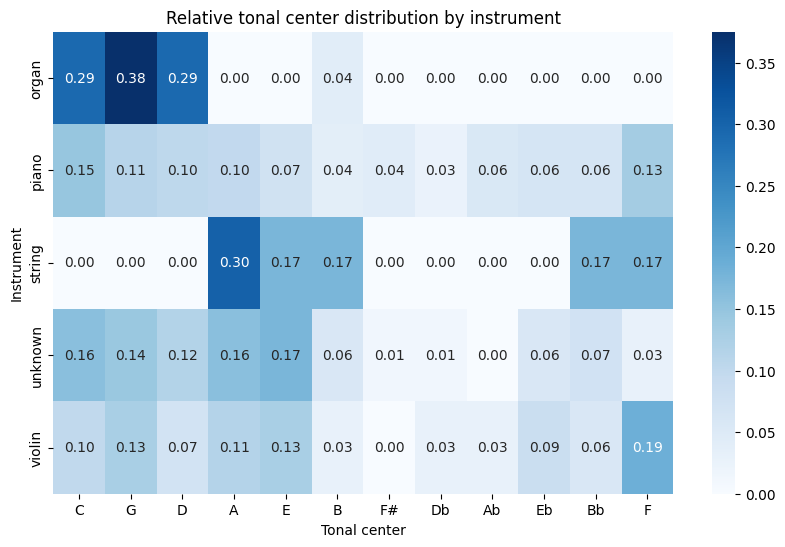

In [338]:
instrument_key_norm = pd.crosstab(
    metadata["instrument_clean"],
    metadata["tonic"],
    normalize="index"
)
# again this is just for visualization purposes
key_order = [
    "C","G","D","A","E","B",
    "F#","Db","Ab","Eb","Bb","F"
]
instrument_key_norm = instrument_key_norm.reindex(columns=key_order)
plt.figure(figsize=(10,6))
sns.heatmap(
    instrument_key_norm,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)
plt.title("Relative tonal center distribution by instrument")
plt.xlabel("Tonal center")
plt.ylabel("Instrument")
plt.show()

We can see that piano is pretty spread out across many tonal centers, which makes sense since piano repertoire covers a wide range of keys. Organ pieces seem to cluster heavily around G, C, and D, probably because those keys are historically common in organ music. String pieces look more concentrated in A, E, and B, which also makes sense since those are comfortable keys for string instruments. I would say these patterns seem to reflect very practical and at times historical instrument preferences for certain keys, but not in a systematic way.

### Tonic by tonal mode by corpus

Last but not least, it is good to check if tonic and tonal mode together differ by corpus. Although I could simply use the annotated_key column for this analysis since it contains both pieces of information at once, I decided to aggregate my 2 new variables (mode and tonic) simply to aid with the interpretation of the results.

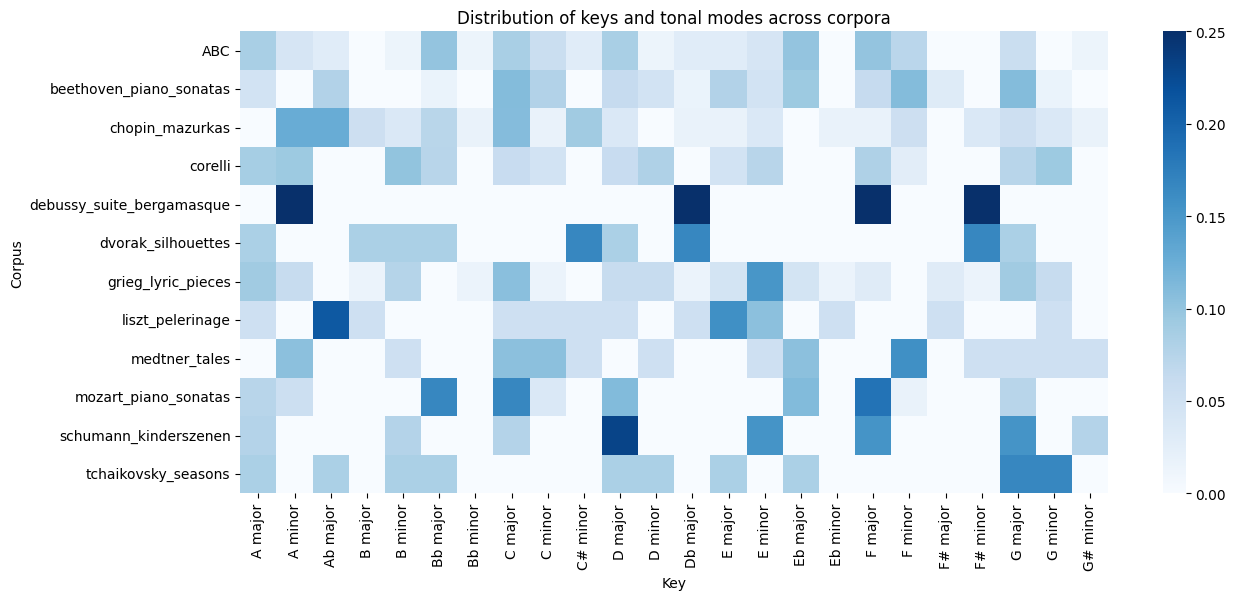

In [339]:
metadata["key_mode"] = metadata["tonic"] + " " + metadata["mode"]
corpus_keymode = pd.crosstab(
    metadata["corpus"],
    metadata["key_mode"],
    normalize="index"
)
plt.figure(figsize=(14,6))
sns.heatmap(
    corpus_keymode,
    cmap="Blues"
)
plt.title("Distribution of keys and tonal modes across corpora")
plt.xlabel("Key")
plt.ylabel("Corpus")
plt.show()

The heatmap shows which keys come up more often in each corpus. You can see that different composers seem to favor certain keys. For example, some corpora like Debussy’s Suite Bergamasque have very strong concentration in just a few keys, while others like Mozart and Beethoven piano sonatas are more spread out across different tonalities. Overall it just shows that key usage varies quite a bit between composers and datasets, which isn’t surprising since composers often have stylistic preferences for certain tonal centers.

## *Numerical relationships*

In this section, I will investigate the most relevant relationships between my numerical variables with a correlation heatmap. In the project, I am only working with the categorical variables investigated before (tonal mode being the main one), however it is good to visualize the relationships between my numerical variables to see what my data looks like.

### Correlation between numerical variables

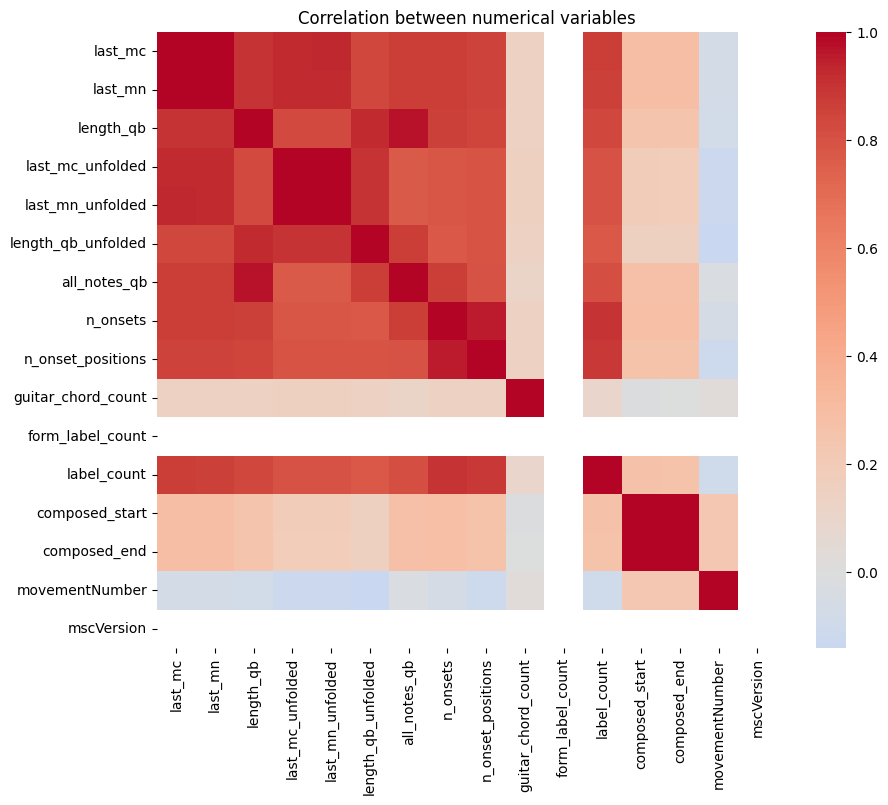

In [340]:
numeric_cols = metadata.select_dtypes(include=["int64","float64"])
corr = numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between numerical variables")
plt.show()

Here, we can see that a lot of the numeric variables are very strongly correlated with each other, especially the ones related to piece length and musical events. Musical concepts like length_qb, all_notes_qb, n_onsets, and n_onset_positions all move together, which makes sense because longer pieces naturally have more notes and more onset positions. Some of the “unfolded” versions of variables are also almost perfectly correlated with their original versions, which just means they’re measuring almost the same thing. Overall, this is mostly to confirm that piece length is the main factor driving many of these numeric features.

## Analysis 7: Statistical testing

### T-test for differences in piece lenght between major and minor pieces

In [344]:
major = metadata[metadata["mode"]=="major"]["length_qb"]
minor = metadata[metadata["mode"]=="minor"]["length_qb"]
t_stat, p_value = ttest_ind(major, minor, equal_var=False)
print("Tonal mode (mode) vs Piece length (length_qb)")
print(f"Major pieces: n={len(major)}, mean={np.mean(major):.2f}, std={np.std(major):.2f}")
print(f"Minor pieces: n={len(minor)}, mean={np.mean(minor):.2f}, std={np.std(minor):.2f}")
print("\nT-test results")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.4f}")
# p value common treshold is 0.05 so i will use that to determine statistically significant differences
alpha = 0.05
if p_value < alpha:
    print("\nResult: The difference is statistically significant.")
else:
    print("\nResult: There is no statistically significant difference.")

Tonal mode (mode) vs Piece length (length_qb)
Major pieces: n=321, mean=351.21, std=311.42
Minor pieces: n=216, mean=316.15, std=309.81

T-test results
t-statistic = 1.281
p-value     = 0.2009

Result: There is no statistically significant difference.


From the t-test results we can conclude that major pieces in the dataset are a bit longer on average than minor ones (about 351 vs 316 quarter beats), but the difference isn’t big enough to be statistically meaningful. The t-test gives a p-value of about 0.20, which is well above the usual 0.05 threshold, so I can’t really say that tonal mode has any real effect on piece length here. In other words, major and minor pieces seem to be roughly similar in length overall, and the small difference we see is probably just random variation in the dataset.

### Chi-square test for differences in tonic between major and minor pieces

In [360]:
table = pd.crosstab(metadata["tonic"], metadata["mode"])
chi2, p, dof, expected = chi2_contingency(table)
print("Tonic vs Tonal mode")
print(table)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p:.4f}")
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(f"Cramer's V           = {cramers_v:.3f}")

alpha = 0.05
if p < alpha:
    print("\nResult: There is a statistically significant relationship between tonic and mode.")
else:
    print("\nResult: No statistically significant relationship detected between tonic and mode.")

# check chi-square assumptions by looking at the expected counts 
total_cells = expected.size
low_cells = (expected < 5).sum().sum()
print(f"Cells with expected count <5: {low_cells}/{total_cells} ({low_cells/total_cells:.2%})")
if low_cells/total_cells > 0.2:
    print("Assumption violated")

Tonic vs Tonal mode
mode   major  minor
tonic              
A         36     34
Ab        19      0
B          6     27
Bb        34      3
C         48     23
C#         0     11
D         37     22
Db         9      0
E         22     34
Eb        25      3
F         39     23
F#         5      7
G         41     25
G#         0      4
Chi-square statistic = 106.759
Degrees of freedom   = 13
p-value              = 0.0000
Cramer's V           = 0.446

Result: There is a statistically significant relationship between tonic and mode.
Cells with expected count <5: 5/28 (17.86%)


This test suggests that tonic and tonal mode are strongly related in the dataset. The p-value is essentially zero, which means the relationship is very unlikely to be due to chance. Looking at the counts, we can see why. Some tonics appear almost exclusively in one mode. For example, C# and G# only appear in minor, while Ab and Db only appear in major in this dataset. The cramér’s V value of about 0.45 also suggests the relationship is fairly strong. So overall, certain tonal centers seem to be clearly associated with either major or minor pieces in this corpus. 

This result is a reflection of what we know about Western tonal music, where certain tonal centers tend to appear more frequently in either major or minor contexts. This confirms to me that tonal mode is a meaningful structural feature in the dataset, and also highlights the importance of comparing the probing results to the pitch-class histogram baseline later in the study to make sure that any predictive performance we observe with the main model is not due to surface-level pitch statistics. The effect size is pretty large, so it would be plausible to assume at this stage that pitch distribution information alone may already encode substantial information about mode, but this is not enough ground to fully support this hypothesis as a more compelx model needs to be trained to verify this as well.

### Chi-square test for differences in tonal mode across different instruments

In [359]:
table = pd.crosstab(metadata["instrument_clean"], metadata["mode"])
chi2, p, dof, expected = chi2_contingency(table)

print("Tonal mode vs Instrument type")
print(table)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p:.4f}")
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(f"Cramer's V           = {cramers_v:.3f}")
alpha = 0.05
if p < alpha:
    print("\nResult: There is a statistically significant relationship between instrument type and tonal mode.")
else:
    print("\nResult: No statistically significant relationship between instrument type and tonal mode.")

# check chi-square assumptions by looking at the expected counts 
total_cells = expected.size
low_cells = (expected < 5).sum().sum()
print(f"Cells with expected count <5: {low_cells}/{total_cells} ({low_cells/total_cells:.2%})")
if low_cells/total_cells > 0.2:
    print("Assumption violated")

Tonal mode vs Instrument type
mode              major  minor
instrument_clean              
organ                10     14
piano               149     83
string               11     12
unknown              44     25
violin               46     24
Chi-square statistic = 7.169
Degrees of freedom   = 4
p-value              = 0.1272
Cramer's V           = 0.131

Result: No statistically significant relationship between instrument type and tonal mode.
Cells with expected count <5: 0/10 (0.00%)


The test suggests that instrument type and tonal mode don’t really have a meaningful relationship in this dataset. The p-value is about 0.13, which is above the usual 0.05 threshold, so I can’t say the differences we see are statistically significant. Even though some instruments seem to have more major than minor pieces (like piano and violin), the overall pattern isn’t strong enough to conclude that certain instruments tend to favor a particular mode. The cramér’s V value is also pretty small (~0.13), which indicates that the relationship, if anything, is weak.

### Chi-square test for differences in tonal mode across the corpuses

In [358]:
table = pd.crosstab(metadata["corpus"], metadata["mode"])
chi2, p, dof, expected = chi2_contingency(table)

print("Tonal Mode vs Corpus")
print(table)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p:.4f}")
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(f"Cramer's V           = {cramers_v:.3f}")
alpha = 0.05
if p < alpha:
    print("\nResult: There is a statistically significant relationship between corpus and tonal mode.")
else:
    print("\nResult: No statistically significant relationship between corpus and tonal mode.")

# check chi-square assumptions by looking at the expected counts 
total_cells = expected.size
low_cells = (expected < 5).sum().sum()
print(f"Cells with expected count <5: {low_cells}/{total_cells} ({low_cells/total_cells:.2%})")
if low_cells/total_cells > 0.2:
    print("Assumption violated")


Tonal Mode vs Corpus
mode                       major  minor
corpus                                 
ABC                           49     21
beethoven_piano_sonatas       45     19
chopin_mazurkas               28     27
corelli                       72     77
debussy_suite_bergamasque      2      2
dvorak_silhouettes             7      5
grieg_lyric_pieces            35     31
liszt_pelerinage              13      6
medtner_tales                  5     14
mozart_piano_sonatas          48      6
schumann_kinderszenen          9      4
tchaikovsky_seasons            8      4
Chi-square statistic = 46.538
Degrees of freedom   = 11
p-value              = 0.0000
Cramer's V           = 0.294

Result: There is a statistically significant relationship between corpus and tonal mode.
Cells with expected count <5: 4/24 (16.67%)


The chi-square test suggests that the distribution of major and minor pieces does vary across the different corpora. The p-value is essentially zero, so the relationship is statistically significant. Looking at the counts, some corpuses are clearly more balanced (like Corelli and Chopin mazurkas), while others lean strongly toward major, like the Mozart piano sonatas. The cramér’s V value of about 0.29 suggests a moderate relationship, so the corpus a piece comes from does have some influence on whether it’s major or minor, which again makes sense since different composers and collections tend to favor different tonalities.

### Chi-square test for differences in tonal mode across time signatures

Because some of the time signatures in the dataset are really small in sample size, this could create problems with a Chi-square test since one of the assumptions is an expected count of > 5. I will therefore remove the time signatures that have small sample sizes and only use the remaining ones to perform the test.

In [357]:
# i inspected the expected counts and I can see that the low counts are in the less common time signatures, so I will exclude those from the analysis
metadata_filtered = metadata[~metadata["timesig_simple"].isin(["2/8", "9/16", "4/8", "9/8", "6/4"])]
table = pd.crosstab(metadata_filtered["timesig_simple"], metadata_filtered["mode"])

chi2, p, dof, expected = chi2_contingency(table)

print("Tonal mode vs Time signature")
print(table)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p:.4f}")
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(f"Cramer's V           = {cramers_v:.3f}")

alpha = 0.05
if p < alpha:
    print("\nResult: There is a statistically significant relationship between time signature and tonal mode.")
else:
    print("\nResult: No statistically significant relationship between time signature and tonal mode.")

# check chi-square assumptions by looking at the expected counts 
total_cells = expected.size
low_cells = (expected < 5).sum().sum()
print(f"Cells with expected count <5: {low_cells}/{total_cells} ({low_cells/total_cells:.2%})")

if low_cells/total_cells > 0.2:
    print("Assumption violated")


Tonal mode vs Time signature
mode            major  minor
timesig_simple              
12/8                6      4
2/2                22     16
2/4                57     21
3/2                 4     10
3/4                96     70
3/8                10      4
4/4                86     67
6/8                30     19
Chi-square statistic = 13.339
Degrees of freedom   = 7
p-value              = 0.0643
Cramer's V           = 0.160

Result: No statistically significant relationship between time signature and tonal mode.
Cells with expected count <5: 1/16 (6.25%)


This last test suggests that time signature and tonal mode don’t really have a strong relationship in this dataset. The p-value is about 0.06, which is above the usual 0.05 threshold, so we can’t say the differences we see are statistically significant. Even though some meters seem to have slightly more major or minor pieces, the pattern isn’t strong and not consistent enough to conclude that time signature influences tonal mode. The cramér’s V value (~0.16) also points to a pretty weak relationship overall, so meter and mode seem to be mostly independent here.

## Analysis 8: Baseline

### *Simple baseline: majority classifier*

For the baseline, I will compute a simple majority-class baseline.

In [352]:
class_distribution = metadata["mode"].value_counts(normalize=True)
baseline_accuracy = class_distribution.max()
print("Class distribution:")
print(class_distribution)
print("\nMajority class baseline accuracy:")
print(round(baseline_accuracy, 3))

Class distribution:
mode
major    0.597765
minor    0.402235
Name: proportion, dtype: float64

Majority class baseline accuracy:
0.598


Since the dataset contains 321 major pieces (59.8%) and 216 minor pieces (40.2%), a simple classifier that always predicts the majority class (major) would then achieve an accuracy of approximately 59.8%. Naturally, any predictive model that I will train in the main analysis would ideally exceed this performance to demonstrate meaningful predictive power.

##